# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

*Notes:* 

- Solve the questions with python.

- Round the final answer to three decimal places.

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math

## Bernoulli's Distribution

In a basket containing 100 fruits, there are 60 apples and 40 oranges. 

A fruit is picked randomly from the basket. 

1. **What is the probability that the fruit is apple?**
1. **What is the probability that it is an orange?**

In [ ]:
"""
Calculate:
p = probability that the fruit is an apple 
q = probability that the fruit is an orange
"""

##What is the probability that the fruit is apple?

p = (60/100)
print(f"Probability of pciking an apple: {p}")

##What is the probability that it is an orange?
q = 1-p
print(f"Probability of picking an orange: {q}")

Probability of pciking an apple: 0.6
Probability of pciking an orange: 0.4


Now we take a random sample of 20 fruits from the basket. After each fruit is taken, a new fruit of the same type is replaced in the basket. Therefore, every time we are taking 1 fruit from 100 fruits. 

1. **What is the probability that the first 5 fruits are all apples?**

1. **What is the probability that the first 5 fruits are all apples and the next 15 fruits are all oranges?**

You can include the `p` and `q` probabilities you previous calculated in your solution.

In [40]:
##1. **What is the probability that the first 5 fruits are all apples?**

five_apples = p**5
print(f"Probability of picking 5 apples: {five_apples}")

##1. **What is the probability that the first 5 fruits are all apples and the next 15 fruits are all oranges?**
five_apples_15_oranges = five_apples* (q**15)
print(f"Probability of picking 5 apples and 15 oranges: {five_apples_15_oranges:.9f}")




Probability of picking 5 apples: 0.07775999999999998
Probability of picking 5 apples and 15 oranges: 0.000000083


## Binomial Distribution

Similar to the above problem, this time again we randomly sample 20 fruits.

**What is the probability that this time the sample contains 5 apples and 15 oranges?**

Please note that this time the order of the fruits being picked does not matter.

In [ ]:
# your solution here
#Binomial equation: P(X = k) = C(n,k) * p^k * (1-p)^(n-k) 

#(total fruits sampled)
n = 20 
#(number of apples we want) 
k = 5 
#(probability of getting an apple) 
p = 0.6
#(number of ways to arrange 5 apples among 20 fruits)
# "C(n,k)" =  n! / (k! × (n-k)!)

n_factorial = 1
for i in range(1, n + 1):
    n_factorial *= i

k_factorial = 1
for i in range(1, k + 1):
    k_factorial *= i

n_minus_k_factorial = 1
for i in range(1, (n - k) + 1):
    n_minus_k_factorial *= i


combinations = n_factorial // (k_factorial * n_minus_k_factorial)
p_k = p**k                  
q_n_minus_k = q**(n-k)      


binomial_p =  combinations * p_k * q_n_minus_k 
print(binomial_p)


0.0012944935222876579


In the lesson we also discussed CDF (cumulative distribution function). In the context of the above problem, **what is the probability that less than 5 fruits picked are apples?**

Write the formula and calculate the probability below.

In [46]:
# your code here
def binomial_equation(n, k, p):
    """Calculate P(X = k) for binomial distribution"""
    combination = math.factorial(n) / (math.factorial(k) * math.factorial(n - k))
    probability = combination * (p ** k) * ((1 - p) ** (n - k))
    return probability

# Calculate P(X < 5) = P(X <= 4)
prob_less_than_5 = 0

for k in range(5):  # k = 0, 1, 2, 3, 4
    prob_k = binomial_equation(n, k, p)
    prob_less_than_5 += prob_k
    print(f"P(X = {k}) = {prob_k:.10f}")

print(f"P(X < 5) = {prob_less_than_5}")


P(X = 0) = 0.0000000110
P(X = 1) = 0.0000003299
P(X = 2) = 0.0000047004
P(X = 3) = 0.0000423037
P(X = 4) = 0.0002696862
P(X < 5) = 0.00031703112116863


<!-- **Plot the PDF (probability distributiom function) for the above binomial distribution.** -->

**Plot the Probability Mass Function (PMF) for the above binomial distribution.**

*Hint: The range of x in a binomial distribution is from `0` to `n`.*

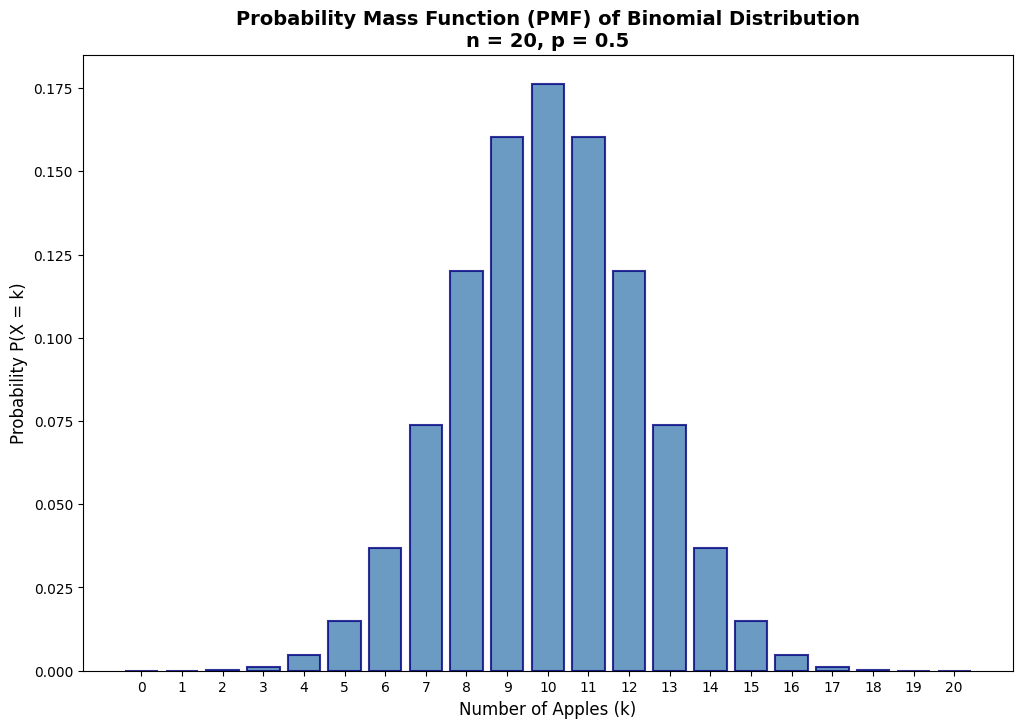

In [64]:
# your code here
# Please label the axes and give a title to the plot 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters for the binomial distribution
n = 20  # number of trials
p = 0.5  # probability of success (picking an apple)

# Create x values from 0 to n
x = np.arange(0, n + 1)  # 0, 1, 2, ..., 20

# Calculate PMF for each x value
pmf_values = binom.pmf(x, n, p)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot the PMF as a bar chart (discrete distribution)
bars = plt.bar(x, pmf_values, alpha=0.8, color='steelblue', edgecolor='navy', linewidth=1.5)


# Add labels and title
plt.xlabel('Number of Apples (k)', fontsize=12)
plt.ylabel('Probability P(X = k)', fontsize=12)
plt.title(f'Probability Mass Function (PMF) of Binomial Distribution\nn = {n}, p = {p}', fontsize=14, fontweight='bold')

# Set x-axis ticks to show all values
plt.xticks(x)
plt.show()


## Poisson Distribution

In this challenge you are required to use the Math library in python to solve the problems.

In the UEFA champions league tournament, the average number of goals scored in a match is 2.3. 

**What is the probability that the number of goals scored in a match is 5?**

*Hint: Use the exp() in the math library*

And to calculate the factorial, you can use the following code:

```python
import math
math.factorial(n) # n is the number you want to find the factorial of
```

In [66]:
# your code here 
import math
lambda_value = 2.3  
k = 5  

# Calculate the probability using Poisson distribution # P(X = k) = (e^(-λ) × λ^k) / k!
probability = (math.exp(-lambda_value) * (lambda_value ** k)) / math.factorial(k)

print(f"The probability of exactly 5 goals being scored is: {probability}")


The probability of exactly 5 goals being scored is: 0.0537750255819468


**Draw a poisson probability distribution plot for the number of goals to be between 0 to 10.**

P(X = 0) = 0.10025884372280375
P(X = 1) = 0.2305953405624486
P(X = 2) = 0.2651846416468159
P(X = 3) = 0.20330822526255884
P(X = 4) = 0.1169022295259713
P(X = 5) = 0.0537750255819468
P(X = 6) = 0.02061375980641294
P(X = 7) = 0.006773092507821395
P(X = 8) = 0.0019472640959986504
P(X = 9) = 0.0004976341578663217
P(X = 10) = 0.00011445585630925399


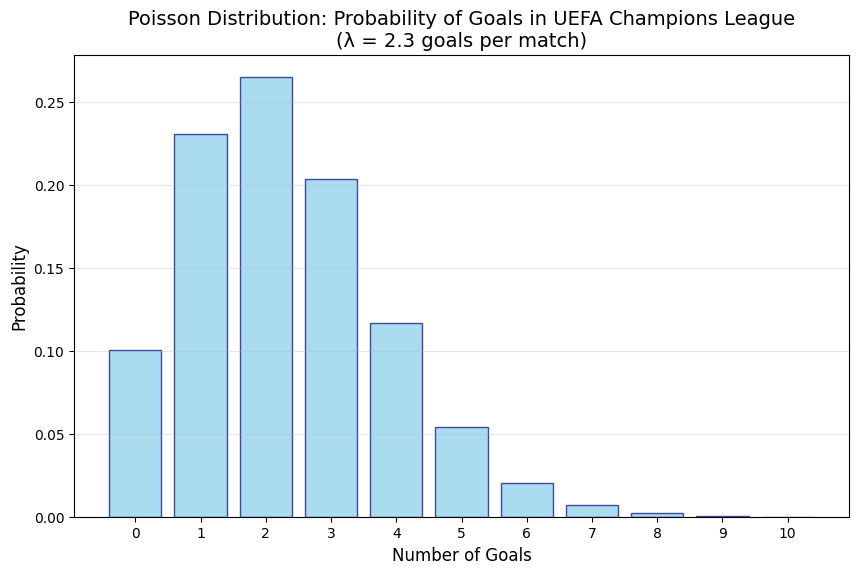

In [ ]:
# your code here
# Please label the axes and give a title to the plot 

lambda_value = 2.3  
k_values = range(0, 11)  

# Calculate probabilities for each k
probabilities = []
for k in k_values:
    prob = (math.exp(-lambda_value) * (lambda_value ** k)) / math.factorial(k)
    probabilities.append(prob)
    print(f"P(X = {k}) = {prob}")

# Create the plot
plt.figure(figsize=(10, 6))
plt.bar(k_values, probabilities, color='skyblue', edgecolor='navy', alpha=0.7)

# Customize the plot
plt.xlabel('Number of Goals', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Poisson Distribution: Probability of Goals in UEFA Champions League\n(λ = 2.3 goals per match)', fontsize=14)
plt.xticks(k_values)
plt.grid(True, axis='y', alpha=0.3)

plt.show()